In [38]:
import pandas as pd

df = pd.read_csv('data/airbnb_listings_stockholm_detailed.csv')


print(df.shape)



(4955, 79)


In [2]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4955 non-null   int64  
 1   listing_url                                   4955 non-null   object 
 2   scrape_id                                     4955 non-null   int64  
 3   last_scraped                                  4955 non-null   object 
 4   source                                        4955 non-null   object 
 5   name                                          4955 non-null   object 
 6   description                                   4763 non-null   object 
 7   neighborhood_overview                         1780 non-null   object 
 8   picture_url                                   4955 non-null   object 
 9   host_id                                       4955 non-null   i

In [3]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [40]:
df = df[[
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "minimum_nights",
    "host_is_superhost"
]]

In [41]:
display(df.describe())
display(df["price"].head(10))

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,number_of_reviews,availability_365,minimum_nights
count,4955.000000,4697.000000,3188.000000,3189.000000,4086.000000,4955.000000,4955.000000,4955.000000
mean,3.502523,1.717479,2.156838,1.287551,4.805999,32.499697,139.374773,7.131786
std,2.023216,1.392828,1.834678,1.091029,0.338684,72.974173,140.441034,24.807856
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,4.750000,1.500000,0.000000,1.000000
50%,3.000000,1.000000,2.000000,1.000000,4.910000,8.000000,86.000000,3.000000
75%,4.000000,2.000000,3.000000,1.500000,5.000000,27.500000,276.000000,5.000000
max,16.000000,50.000000,50.000000,50.000000,5.000000,1239.000000,365.000000,500.000000


0      $917.00
1      $450.00
2    $1,073.00
3      $779.00
4    $2,352.00
5    $1,126.00
6      $950.00
7      $751.00
8    $4,300.00
9    $1,218.00
Name: price, dtype: object

Måste städa den viktigaste kategorin från dollartecken. Bedrooms visar max 50 och min 0 = felaktigt. Samma med beds och bathrooms. Accomotates har max 16, låter mycket måste kolla upp. Men börjar med pris.

In [42]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [43]:
df["price"].describe()

count      3190.000000
mean       1690.473041
std        3704.741906
min         120.000000
25%         753.000000
50%        1200.000000
75%        2000.000000
max      112218.000000
Name: price, dtype: float64

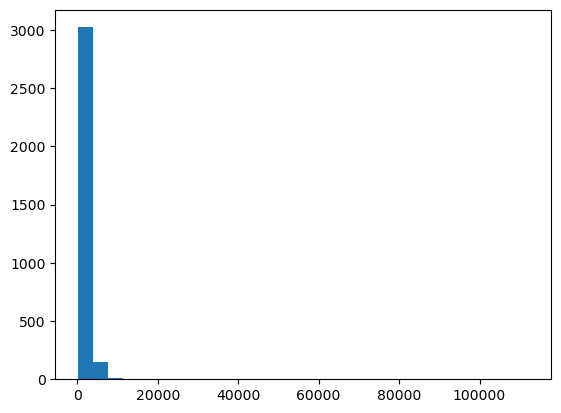

In [44]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=30)
plt.show()

Varför ser prisdatan så orimlig ut?

In [45]:
high = df["price"].sort_values(ascending=False).head(10)
low = df["price"].sort_values().head(10)

print("High prices:")
print(high)
print()
print("Low prices:")
print(low)

High prices:
2508    112218.0
2507    112218.0
2533    111984.0
2085     35000.0
2701     25000.0
2091     17872.0
3585     16000.0
2030     15000.0
114      15000.0
3285     12000.0
Name: price, dtype: float64

Low prices:
2271    120.0
2066    174.0
1834    190.0
2239    190.0
1374    198.0
524     200.0
732     200.0
527     200.0
2541    208.0
3668    210.0
Name: price, dtype: float64


Extrema skillnader i pris mellan högst och lägst, så höga priser per natt ser orimliga ut. Vill kolla in mer data på Outliers.

In [46]:
cheap_apt = df[df["price"] < 300][["price", "room_type", "accommodates", "beds", "neighbourhood_cleansed"]]
expensive_apt = df[df["price"] > 16000][["price", "room_type", "accommodates", "beds", "neighbourhood_cleansed"]]

print(cheap_apt)
print()
print(expensive_apt)

      price     room_type  accommodates  beds  neighbourhood_cleansed
30    262.0  Private room             4   3.0             Skärholmens
69    210.0  Private room             1   1.0  Hägersten-Liljeholmens
121   254.0  Private room             1   1.0  Hägersten-Liljeholmens
214   250.0  Private room             1   1.0              Skarpnäcks
290   241.0  Private room             1   1.0  Hägersten-Liljeholmens
...     ...           ...           ...   ...                     ...
4494  244.0   Shared room             1   2.0           Spånga-Tensta
4716  296.0  Private room             2   1.0          Rinkeby-Tensta
4717  285.0  Private room             1   1.0      Hässelby-Vällingby
4917  280.0  Private room             1   1.0                  Farsta
4951  272.0  Private room             2   1.0              Södermalms

[68 rows x 5 columns]

         price        room_type  accommodates  beds neighbourhood_cleansed
2085   35000.0  Entire home/apt             4   2.0          

De billiga lägenheterna verkar vara privata rum utanför staden så de är nog rimliga. Men de privata rummen för 112 218 kr kan man nog anta är felaktiga. Jag ser två saker nu, man borde förmodligen separera room_type för att få fram intressant data. Sedan verkar accommodates och beds inte lira så bra ihop, så jag vill kika på vilken av de två man kan lita på.

In [47]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,2540.0,1781.735433,1562.836297,210.0,900.0,1386.0,2250.00,35000.0
Hotel room,1.0,303.000000,NaN,303.0,303.0,303.0,303.00,303.0
Private room,621.0,1374.236715,7770.818047,120.0,394.0,597.0,969.00,112218.0
Shared room,28.0,474.892857,294.857698,244.0,291.5,366.0,508.75,1312.0



1 hotel room = ta bort.  Private room får uppenbarligen fel mean pga den höga outliern. Så, låt oss ta bort dem och testa igen!

In [48]:
df = df[df["price"] < 30000]

In [49]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,2539.0,1768.652225,1417.207012,210.0,900.00,1385.0,2250.00,25000.0
Hotel room,1.0,303.000000,NaN,303.0,303.00,303.0,303.00,303.0
Private room,618.0,836.538835,857.047373,120.0,393.25,597.0,957.50,10000.0
Shared room,28.0,474.892857,294.857698,244.0,291.50,366.0,508.75,1312.0


Efter att extrema värden filtrerats bort framträder tydliga skillnader mellan olika typer av boenden. Entire home/apt är generellt dyrast, följt av Private room, medan Shared room är billigast. Detta visar att room_type är en av de viktigaste faktorerna som påverkar priset.
Låt oss undersöka lite om det finns knasigheter mellan accomodates och beds. Rimligtvis borde antal sängar öka med större kapacitet för boende.

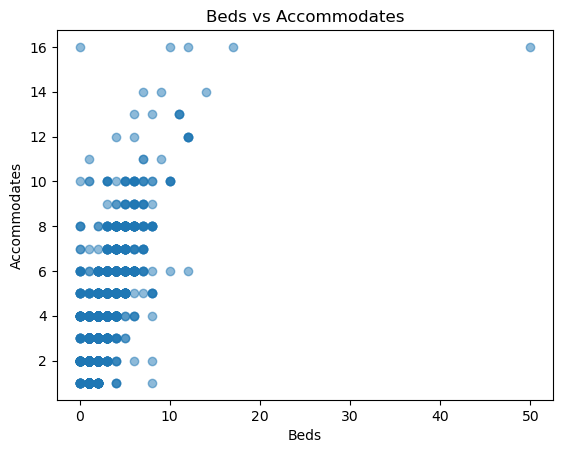

In [50]:
import matplotlib.pyplot as plt

plt.scatter(df["beds"], df["accommodates"], alpha=0.5)
plt.xlabel("Beds")
plt.ylabel("Accommodates")
plt.title("Beds vs Accommodates")
plt.show()

Scatterplotten visar ett tydligt positivt samband mellan beds och accommodates, men också flera avvikande värden och inkonsekvenser, såsom orimligt många sängar eller inga sängar alls. Detta tyder på brister i datakvaliteten för variabeln beds.

Variabeln accommodates bedöms därför vara mer tillförlitlig, eftersom den direkt representerar hur många gäster ett boende är avsett för.

Datasetet saknar dessutom en direkt variabel för fysisk storlek, såsom kvadratmeter, vilket innebär att accommodates används som ett indirekt mått på storlek i den fortsatta analysen.


Nu vill jag kika lite på kolumner med tomma värden!

In [51]:
df.isnull().sum()

price                       0
accommodates                0
bedrooms                   12
beds                        2
bathrooms                   1
room_type                   0
property_type               0
neighbourhood_cleansed      0
review_scores_rating      524
number_of_reviews           0
availability_365            0
minimum_nights              0
host_is_superhost          20
dtype: int64

In [52]:
df["host_is_superhost"] = df["host_is_superhost"].map({"t": 1, "f": 0})
df["host_is_superhost"] = df["host_is_superhost"].fillna(0)

Variabeln host_is_superhost innehöll kategoriska värden (“t” och “f”) och konverterades till numeriska värden för att underlätta analys. Saknade värden antogs motsvara icke-superhost.

Slutsats inför vidare analyser. Variablarna jag ser som mest intressanta är price, accommodates, room_type (sortera), neighbourhood, ratings vore ju bra kan man tycka, men 516 rader är tomma där. Isåfall måste jag lösa situationen med lägenheter som saknar ratings om man ska använda den variabeln.

In [53]:
#Tar bort hotellrummet och kategorin beds (går efter accommodates istället)
df = df[df["room_type"] != "Hotel room"]
df = df.drop(columns=["beds"])

In [54]:
df["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Södermalms                806
Norrmalms                 307
Kungsholmens              298
Hägersten-Liljeholmens    283
Enskede-Årsta-Vantörs     281
Bromma                    217
Östermalms                213
Skarpnäcks                163
Älvsjö                    127
Farsta                    111
Hässelby-Vällingby        111
Rinkeby-Tensta            107
Skärholmens                83
Spånga-Tensta              78
Name: count, dtype: int64

In [55]:
df.groupby("neighbourhood_cleansed")["price"].mean()

neighbourhood_cleansed
Bromma                    1797.211982
Enskede-Årsta-Vantörs     1345.032028
Farsta                    1532.738739
Hägersten-Liljeholmens    1470.275618
Hässelby-Vällingby        1358.873874
Kungsholmens              1542.043624
Norrmalms                 1831.488599
Rinkeby-Tensta             840.757009
Skarpnäcks                1227.055215
Skärholmens                826.638554
Spånga-Tensta             1025.205128
Södermalms                1761.612903
Älvsjö                    1647.370079
Östermalms                2002.159624
Name: price, dtype: float64

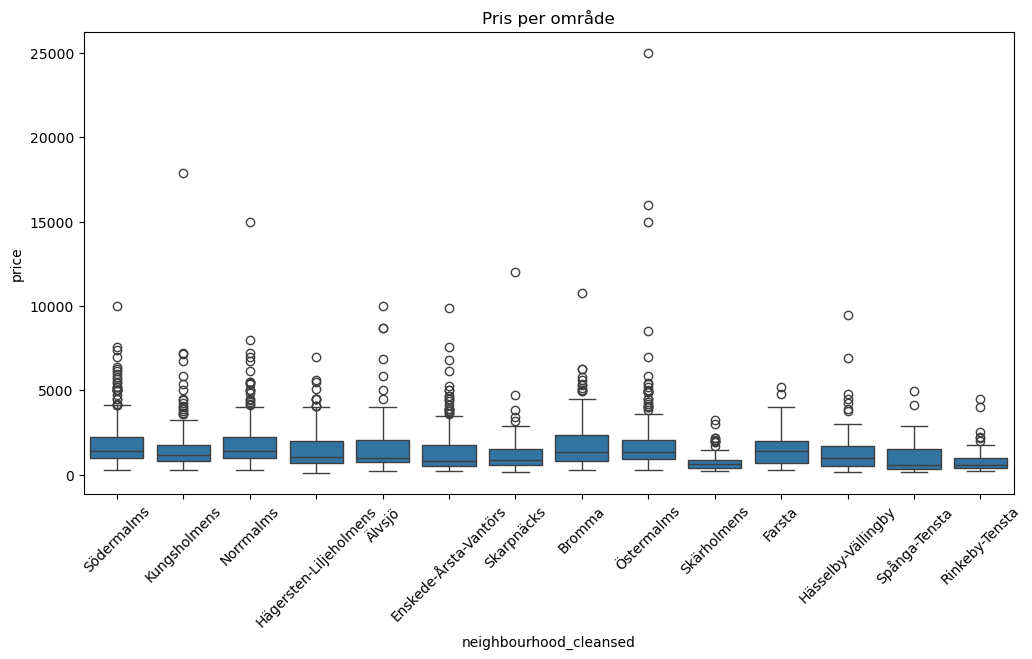

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x="neighbourhood_cleansed", y="price", data=df)
plt.xticks(rotation=45)
plt.title("Pris per område")
plt.show()

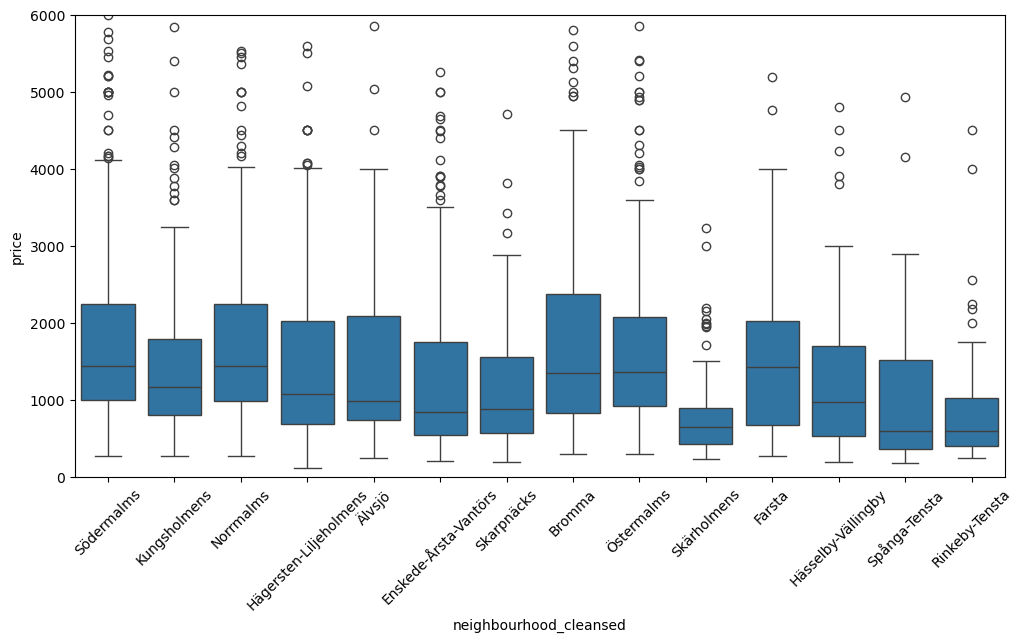

In [57]:
plt.figure(figsize=(12,6))
sns.boxplot(x="neighbourhood_cleansed", y="price", data=df)
plt.ylim(0, 6000)
plt.xticks(rotation=45)
plt.show()

Jag vill titta på bostäder med outliers i accommodations.

In [58]:
df.sort_values("accommodates", ascending=False)[
    ["price", "accommodates", "room_type", "bedrooms", "neighbourhood_cleansed"]
].head(10)

,price,accommodates,room_type,bedrooms,neighbourhood_cleansed
86,3166.0,16,Entire home/apt,6.0,Enskede-Årsta-Vantörs
4442,2743.0,16,Entire home/apt,8.0,Älvsjö
1084,3873.0,16,Entire home/apt,4.0,Södermalms
3435,4715.0,16,Entire home/apt,2.0,Skarpnäcks
3929,1533.0,16,Private room,50.0,Enskede-Årsta-Vantörs
4182,269.0,14,Shared room,1.0,Kungsholmens
2249,2546.0,14,Entire home/apt,6.0,Hägersten-Liljeholmens
2739,5039.0,14,Entire home/apt,5.0,Älvsjö
838,2972.0,13,Entire home/apt,3.0,Södermalms
852,6950.0,13,Entire home/apt,5.0,Hässelby-Vällingby


Lite fuffens med rum där man kan bo 16 personer, så vill undersöka detta närmare.

In [59]:
df[
    (df["room_type"].isin(["Private room", "Shared room"])) &
    (df["accommodates"] > 6)
][
    ["price", "accommodates", "bedrooms", "room_type", "neighbourhood_cleansed"]
].sort_values("accommodates", ascending=False)

,price,accommodates,bedrooms,room_type,neighbourhood_cleansed
3929,1533.0,16,50.0,Private room,Enskede-Årsta-Vantörs
4182,269.0,14,1.0,Shared room,Kungsholmens
3190,304.0,12,1.0,Shared room,Östermalms
4181,269.0,12,NaN,Shared room,Kungsholmens
4590,500.0,11,1.0,Private room,Skärholmens
1410,3913.0,10,1.0,Private room,Hässelby-Vällingby
3193,300.0,10,1.0,Shared room,Östermalms
4327,2662.0,10,1.0,Private room,Östermalms
3192,309.0,8,1.0,Shared room,Östermalms
4048,2692.0,8,1.0,Private room,Kungsholmens


Det är uppenbart att det finns en del felaktigheter i rum vs accommodates, för att kunna använda skillnaden i pris efter rumstyp vill jag sortera bort dessa.

In [60]:
df_before = df.copy()

#Gör kopia på dataset

In [61]:
df = df[~(
    ((df["room_type"] == "Private room") & (df["accommodates"] > 6)) |
    ((df["room_type"] == "Shared room") & (df["accommodates"] > 8))
)]

#Tar bort alla enskilda rum med orimligt många boende

Orimliga datapunkter identifierades och togs bort från datasetet, då de sannolikt representerar felaktig information snarare än extrema men korrekta observationer.

In [62]:
print("Antal poster som sorterades bort baserat på för många boende i rum:")
print(len(df_before) - len(df))

Antal poster som sorterades bort baserat på för många boende i rum:
9


In [63]:
df["accommodates"].describe()

count    3176.000000
mean        3.488980
std         2.037415
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        16.000000
Name: accommodates, dtype: float64

Nu ser datan för antal boende rimlig ut. Vill nu visualisera skillnaden i pris baserat på room_type:

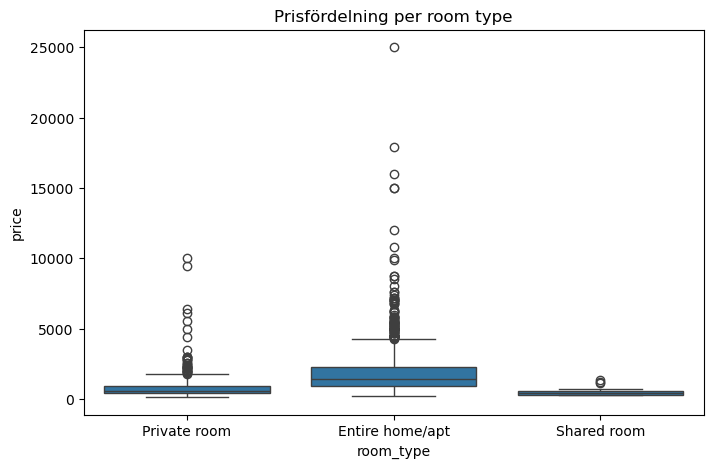

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="room_type", y="price", data=df)
plt.title("Prisfördelning per room type")
plt.show()

En outlier på 35 000 kr natten. Känns som den sabbar datan så går tillbaks i mitt dataset och tar bort den. Tydlig skillnad i pris beroende på rumstyp så vill träna modellen på detta.

Jag vill inte använda ALLA variablar i min modell. och jag vill undersöka property_type lite,

In [31]:
df["property_type"].unique()

array(['Private room in rental unit', 'Entire rental unit',
       'Private room in home', 'Private room in townhouse', 'Entire home',
       'Entire villa', 'Entire condo', 'Entire loft',
       'Private room in condo', 'Entire townhouse',
       'Private room in guesthouse', 'Entire guesthouse',
       'Private room in loft', 'Entire serviced apartment',
       'Shared room in condo', 'Private room in villa',
       'Private room in guest suite', 'Entire guest suite',
       'Private room', 'Private room in casa particular',
       'Private room in bed and breakfast', 'Room in boutique hotel',
       'Shared room in home', 'Entire cottage', 'Entire cabin',
       'Tiny home', 'Private room in hostel', 'Shared room in hostel',
       'Room in hotel', 'Room in aparthotel',
       'Shared room in bed and breakfast',
       'Private room in serviced apartment', 'Private room in tiny home',
       'Boat', 'Casa particular', 'Shared room in rental unit',
       'Camper/RV', 'Shared room in

Variabeln property_type innehöll många detaljerade kategorier, vilket gjorde den svår att använda direkt i modellen. För att göra den mer hanterbar grupperas den därför om till ett mindre antal övergripande kategorier: room, apartment, house och unique.

In [91]:
def simplify_property_type(x):
    x = x.lower()

    if "boat" in x or "camper/rv" in x or "camper" in x:
        return "unique"
    elif any(word in x for word in [
        "condo", "loft", "rental unit", "serviced apartment",
        "aparthotel", "apartment"
    ]):
        return "apartment"
    elif "room" in x:
        return "room"
    else:
        return "house"


df["property_group"] = df["property_type"].apply(simplify_property_type)
df["property_group"].value_counts()

property_group
apartment    2425
house         534
room          207
unique         10
Name: count, dtype: int64

In [92]:
pd.crosstab(
    df["neighbourhood_cleansed"],
    df["property_group"],
    normalize="index"
)

property_group,apartment,house,room,unique
neighbourhood_cleansed,,,,
Bromma,0.506912,0.428571,0.055300,0.009217
Enskede-Årsta-Vantörs,0.664286,0.267857,0.060714,0.007143
Farsta,0.441441,0.531532,0.018018,0.009009
Hägersten-Liljeholmens,0.749117,0.236749,0.010601,0.003534
Hässelby-Vällingby,0.418182,0.445455,0.127273,0.009091
Kungsholmens,0.840678,0.044068,0.111864,0.003390
Norrmalms,0.866450,0.000000,0.133550,0.000000
Rinkeby-Tensta,0.738318,0.130841,0.130841,0.000000
Skarpnäcks,0.699387,0.245399,0.055215,0.000000


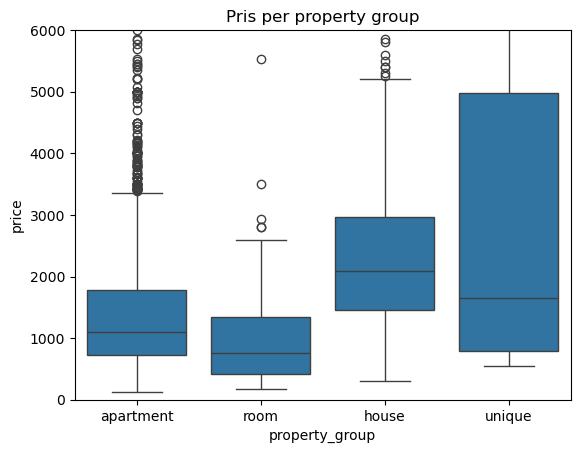

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="property_group", y="price", data=df)
plt.ylim(0, 6000)
plt.title("Pris per property group")
plt.show()

Känns tydligt att nya variabeln funkar bra, ser rimlig ut med en del spretiga värden.

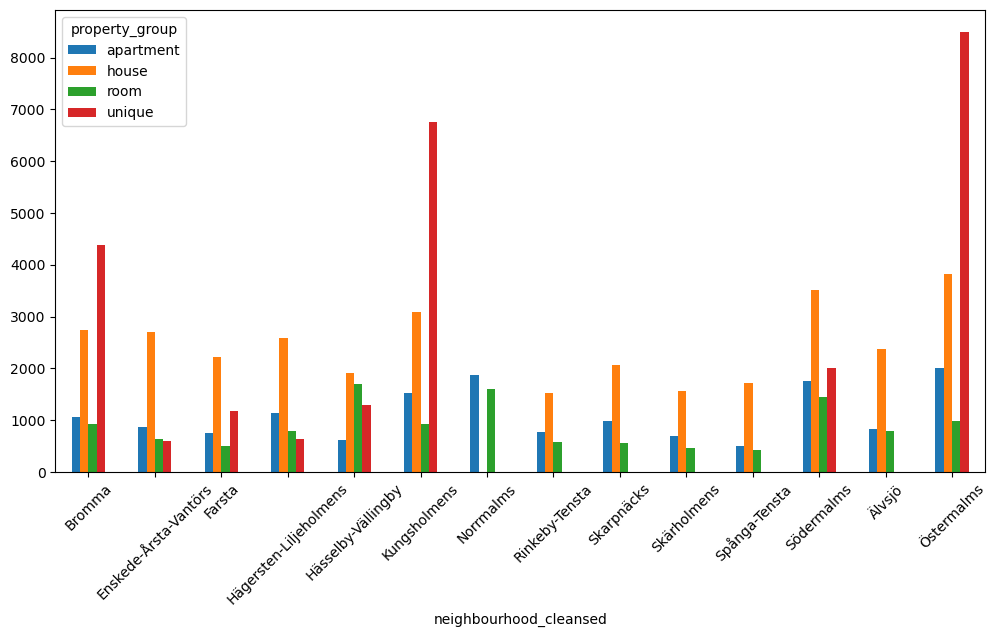

In [94]:
df.groupby(["neighbourhood_cleansed", "property_group"])["price"].mean().unstack().plot(kind="bar", figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [95]:
df_unique = df[df["property_group"] == "unique"]

df_unique[[
    "price",
    "accommodates",
    "room_type",
    "property_type",
    "neighbourhood_cleansed"
]].sort_values("price", ascending=False)

,price,accommodates,room_type,property_type,neighbourhood_cleansed
2148,8500.0,11,Entire home/apt,Boat,Östermalms
3126,6750.0,11,Entire home/apt,Boat,Kungsholmens
4377,5596.0,10,Entire home/apt,Boat,Bromma
4378,3160.0,10,Entire home/apt,Boat,Bromma
4736,2003.0,4,Entire home/apt,Camper/RV,Södermalms
4311,1300.0,2,Entire home/apt,Camper/RV,Hässelby-Vällingby
3967,1175.0,5,Entire home/apt,Camper/RV,Farsta
3948,666.0,2,Entire home/apt,Camper/RV,Enskede-Årsta-Vantörs
4906,631.0,2,Entire home/apt,Camper/RV,Hägersten-Liljeholmens
3888,540.0,2,Entire home/apt,Camper/RV,Enskede-Årsta-Vantörs
